# About this notebook...

The Objective of this notebook is to give an idea how is the workflow in any predictive modeling problem. How do we check features, how do we add new features and some Machine Learning Concepts. I have tried to keep the notebook as basic as possible so that even newbies can understand every phase of it.

You can check out my previous work related to it in some other aproach.[click here](https://www.kaggle.com/saife245/titanic-deep-learning-model-with-80-accuracy)


## <font color='red'>If You Like the notebook and think that it helped you PLEASE UPVOTE.</font>;)

# Introduction...

The sinking of the Titanic is one of the most infamous shipwrecks in history. On April 15, 1912, during her maiden voyage, the Titanic sank after colliding with an iceberg, killing 1502 out of 2224 passengers and crew. That's why the name DieTanic. This is a very unforgetable disaster that no one in the world can forget.

It took about $7.5 million to build the Titanic and it sunk under the ocean due to collision. The Titanic Dataset is a very good dataset for begineers to start a journey in data science and participate in competitions in Kaggle.

The competition is simple: use machine learning to create a model that predicts which passengers survived the Titanic shipwreck.The Titanic Dataset is a very good dataset for begineers to start a journey in data science and participate in competitions in Kaggle.


## Topic will be convered in build the Machine Learning Model..

A) Introduction

B) Load the data

C) Analyze the dataset

D) Feature engineering 

E) Filling missing Values

F) Modeling

G) Prediction



## First understand the Problem statment...

In this challenge, we have to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

In [1]:
#importing library
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# About the dataset..¶
The data has been split into two groups:

training set (train.csv) test set (test.csv) The training set should be used to build your machine learning models. For the training set, we provide the outcome (also known as the “ground truth”) for each passenger. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

The test set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

**Data Defination**

*Variable Definition Key*

* survival Survival 0 = No, 1 = Yes

* pclass Ticket class 1 = 1st, 2 = 2nd, 3 = 3rd

* sex Male or Female

* Age Age in years

* sibsp # of siblings / spouses aboard the Titanic

* parch # of parents / children aboard the Titanic

* ticket Ticket number

* fare Passenger fare

* cabin Cabin number

* embarked Port of Embarkation C = Cherbourg, Q = Queenstown, S = Southampton

* Variable Notes pclass: A proxy for socio-economic status (SES) 1st = Upper 2nd = Middle 3rd = Lower

* age: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

* sibsp: The dataset defines family relations in this way...

* Sibling = brother, sister, stepbrother, stepsister

* Spouse = husband, wife (mistresses and fiancés were ignored)

* parch: The dataset defines family relations in this way...

* Parent = mother, father

* Child = daughter, son, stepdaughter, stepson

* Some children travelled only with a nanny, therefore parch=0 for them

In [2]:
train = pd.read_csv("../input/train.csv")
test = pd.read_csv("../input/test.csv")

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Name           891 non-null object
Sex            891 non-null object
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          204 non-null object
Embarked       889 non-null object
dtypes: float64(2), int64(5), object(5)
memory usage: 83.6+ KB


In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
PassengerId    418 non-null int64
Pclass         418 non-null int64
Name           418 non-null object
Sex            418 non-null object
Age            332 non-null float64
SibSp          418 non-null int64
Parch          418 non-null int64
Ticket         418 non-null object
Fare           417 non-null float64
Cabin          91 non-null object
Embarked       418 non-null object
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


## Analyze the dataset and see the feature effect the Survival

In [7]:
#First check out the survival rate
train['Survived'].value_counts(normalize=True)

0    0.616162
1    0.383838
Name: Survived, dtype: float64

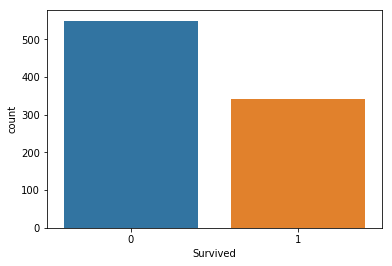

In [8]:
sns.countplot(train['Survived'])

### Pclass

Class played a critical role in survival, as the survival rate decreased drastically for the lowest class. This variable is both useful and clean, and I will be treating it as a categorical variable.

In [9]:
train['Survived'].groupby(train['Pclass']).mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

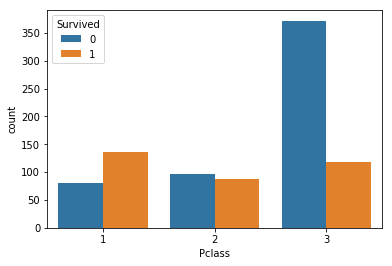

In [10]:
sns.countplot(train['Pclass'], hue=train['Survived'])

**SEX**

Another Important Feature is ** SEX**.Sex matter lot for deciding the survival rate. Women and childern has greater chance of survial than men.let compare the survival rate with sex.

In [11]:
train['Sex'].value_counts(normalize=True)

male      0.647587
female    0.352413
Name: Sex, dtype: float64

In [12]:
#Survival rate w.r.t. sex
train['Survived'].groupby(train['Sex']).mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

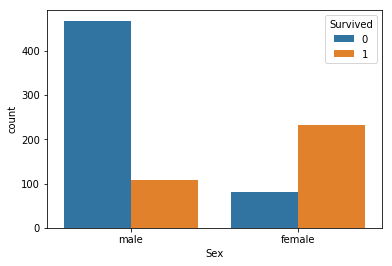

In [13]:
sns.countplot(train['Sex'], hue=train['Survived'])

**Age**

As sex affect the survival rate. Age also matter a lot for deciding the survival rate.Before comparing the survival with Age, we have to handle the missing value of age columns.

In [14]:
train['Survived'].groupby(pd.qcut(train['Age'],5)).mean()

Age
(0.419, 19.0]    0.481707
(19.0, 25.0]     0.328467
(25.0, 31.8]     0.393701
(31.8, 41.0]     0.437500
(41.0, 80.0]     0.373239
Name: Survived, dtype: float64

In [15]:
pd.qcut(train['Age'],5).value_counts()

(0.419, 19.0]    164
(31.8, 41.0]     144
(41.0, 80.0]     142
(19.0, 25.0]     137
(25.0, 31.8]     127
Name: Age, dtype: int64

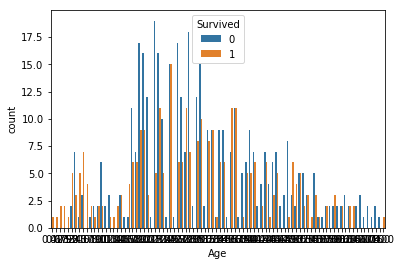

In [16]:
sns.countplot(train['Age'], hue=train['Survived'])

In [17]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Name           891 non-null object
Sex            891 non-null object
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          204 non-null object
Embarked       889 non-null object
dtypes: float64(2), int64(5), object(5)
memory usage: 83.6+ KB


**Sibsp** 

In [18]:
train['Survived'].groupby(train['SibSp']).mean()

SibSp
0    0.345395
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: Survived, dtype: float64

In [19]:
train['SibSp'].value_counts()

0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: SibSp, dtype: int64

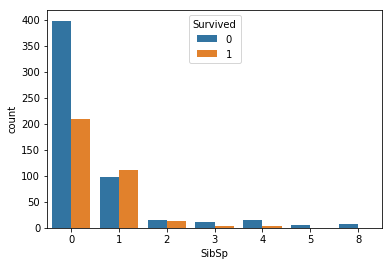

In [20]:
sns.countplot(train['SibSp'], hue=train['Survived'])

## Parch...

passengers with zero parents or children had a lower likelihood of survival than otherwise, but that survival rate was only slightly less than the overall population survival rate.

In [21]:
train['Survived'].groupby(train['Parch']).mean()

Parch
0    0.343658
1    0.550847
2    0.500000
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: Survived, dtype: float64

In [22]:
train['Parch'].value_counts()

0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: Parch, dtype: int64

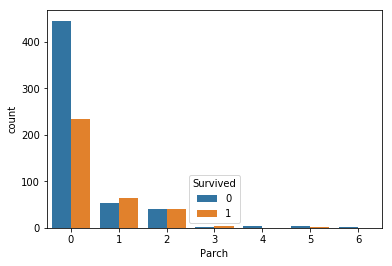

In [23]:
sns.countplot(train['Parch'], hue=train['Survived'])

## Ticket..

Not all factor directly contribute in deciding factor of survival.Just like Ticket column,but it may help in deciding other factor which may effect the survival like ticket column help in decid type of ticket each survivar has which help to decide the location of people in it. It can be done with the help of number of characters in the Ticket column.

In [24]:
train['Ticket'].head()

0           A/5 21171
1            PC 17599
2    STON/O2. 3101282
3              113803
4              373450
Name: Ticket, dtype: object

In [25]:
train['Ticket_Length'] = train['Ticket'].apply(lambda x: len(x))

In [26]:
train['Ticket_Length'].value_counts()

6     419
5     131
4     101
8      76
10     41
7      27
9      26
17     14
16     11
13     10
12     10
15      9
11      8
18      6
3       2
Name: Ticket_Length, dtype: int64

In [27]:
#Another important feature is of using ticket first letter as room number
train['Ticket_Letter'] = train['Ticket'].apply(lambda x: str(x)[0])
train['Ticket_Letter'].value_counts()

3    301
2    183
1    146
S     65
P     65
C     47
A     29
W     13
4     10
7      9
F      7
6      6
L      4
5      3
8      2
9      1
Name: Ticket_Letter, dtype: int64

In [28]:
train.groupby(['Ticket_Letter'])['Survived'].mean()

Ticket_Letter
1    0.630137
2    0.464481
3    0.239203
4    0.200000
5    0.000000
6    0.166667
7    0.111111
8    0.000000
9    1.000000
A    0.068966
C    0.340426
F    0.571429
L    0.250000
P    0.646154
S    0.323077
W    0.153846
Name: Survived, dtype: float64

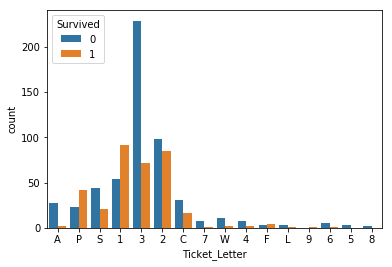

In [29]:
sns.countplot(train['Ticket_Letter'], hue=train['Survived'])

## Fare...

Now looking closely you can figure out that Fare is closely related to Ticket, room, class and survival.

In [30]:
pd.qcut(train['Fare'], 5).value_counts()

(7.854, 10.5]        184
(21.679, 39.688]     180
(-0.001, 7.854]      179
(39.688, 512.329]    176
(10.5, 21.679]       172
Name: Fare, dtype: int64

In [31]:
train['Survived'].groupby(pd.qcut(train['Fare'], 5)).mean()

Fare
(-0.001, 7.854]      0.217877
(7.854, 10.5]        0.201087
(10.5, 21.679]       0.424419
(21.679, 39.688]     0.444444
(39.688, 512.329]    0.642045
Name: Survived, dtype: float64

In [32]:
pd.crosstab(pd.qcut(train['Fare'],10), columns=train['Pclass'])

Pclass,1,2,3
Fare,,,
"(-0.001, 7.55]",6,6,80
"(7.55, 7.854]",0,0,87
"(7.854, 8.05]",0,0,106
"(8.05, 10.5]",0,24,54
"(10.5, 14.454]",0,62,22
"(14.454, 21.679]",0,18,70
"(21.679, 27.0]",26,43,20
"(27.0, 39.688]",38,21,32
"(39.688, 77.958]",59,10,20


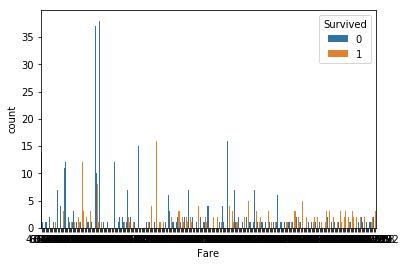

In [33]:
sns.countplot(train['Fare'], hue=train['Survived'])

**Embarked**

Looks like the Cherbourg people had a 20% higher survival rate than the other embarking locations. This is very likely due to the high presence of upper-class passengers from that location.

In [34]:
train['Embarked'].value_counts()

S    644
C    168
Q     77
Name: Embarked, dtype: int64

In [35]:
train['Embarked'].value_counts(normalize=True)

S    0.724409
C    0.188976
Q    0.086614
Name: Embarked, dtype: float64

In [36]:
train['Embarked'].value_counts(normalize=True)

S    0.724409
C    0.188976
Q    0.086614
Name: Embarked, dtype: float64

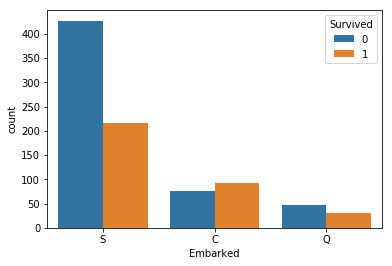

In [37]:
sns.countplot(train['Embarked'], hue=train['Survived'])

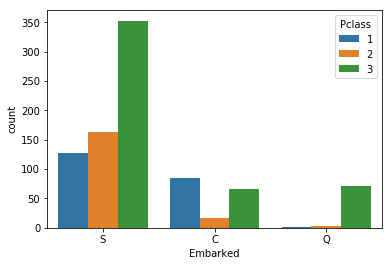

In [38]:
sns.countplot(train['Embarked'], hue=train['Pclass'])

**Name**

I am not very clear about the contribution of name in survival rate. let's try to extract some information from Name.

In [39]:
train['Name'].head()

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: object

In [40]:
train['Name_Title'] = train['Name'].apply(lambda x: x.split(',')[1]).apply(lambda x: x.split()[0])
train['Name_Title'].value_counts()

Mr.          517
Miss.        182
Mrs.         125
Master.       40
Dr.            7
Rev.           6
Mlle.          2
Major.         2
Col.           2
Lady.          1
Capt.          1
Sir.           1
the            1
Jonkheer.      1
Don.           1
Mme.           1
Ms.            1
Name: Name_Title, dtype: int64

In [41]:
train['Survived'].groupby(train['Name_Title']).mean()

Name_Title
Capt.        0.000000
Col.         0.500000
Don.         0.000000
Dr.          0.428571
Jonkheer.    0.000000
Lady.        1.000000
Major.       0.500000
Master.      0.575000
Miss.        0.697802
Mlle.        1.000000
Mme.         1.000000
Mr.          0.156673
Mrs.         0.792000
Ms.          1.000000
Rev.         0.000000
Sir.         1.000000
the          1.000000
Name: Survived, dtype: float64

In [42]:
#let's see any correlation between name lenth and survival
train['Name_Length'] = train['Name'].apply(lambda x: len(x))
train['Survived'].groupby(pd.qcut(train['Name_Length'],5)).mean()

Name_Length
(11.999, 19.0]    0.220588
(19.0, 23.0]      0.301282
(23.0, 27.0]      0.319797
(27.0, 32.0]      0.442424
(32.0, 82.0]      0.674556
Name: Survived, dtype: float64

In [43]:
pd.qcut(train['Name_Length'],5).value_counts()

(11.999, 19.0]    204
(23.0, 27.0]      197
(32.0, 82.0]      169
(27.0, 32.0]      165
(19.0, 23.0]      156
Name: Name_Length, dtype: int64

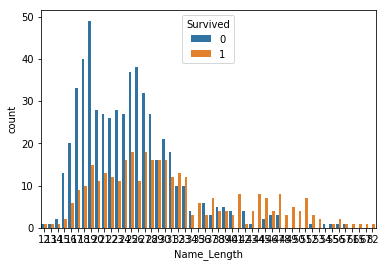

In [44]:
sns.countplot(train['Name_Length'], hue=train['Survived'])

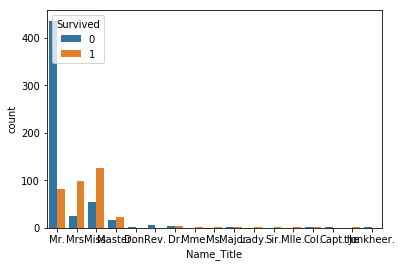

In [45]:
sns.countplot(train['Name_Title'], hue=train['Survived'])

/opt/conda/lib/python3.6/site-packages/seaborn/axisgrid.py:2065: UserWarning: The `size` parameter has been renamed to `height`; pleaes update your code.
  warnings.warn(msg, UserWarning)
/opt/conda/lib/python3.6/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval
/opt/conda/lib/python3.6/site-packages/statsmodels/nonparametric/kde.py:494: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X,a,b,gridsize)/(delta*nobs)
/opt/conda/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2
/opt/conda/lib/python3.6/site-packages/numpy/c

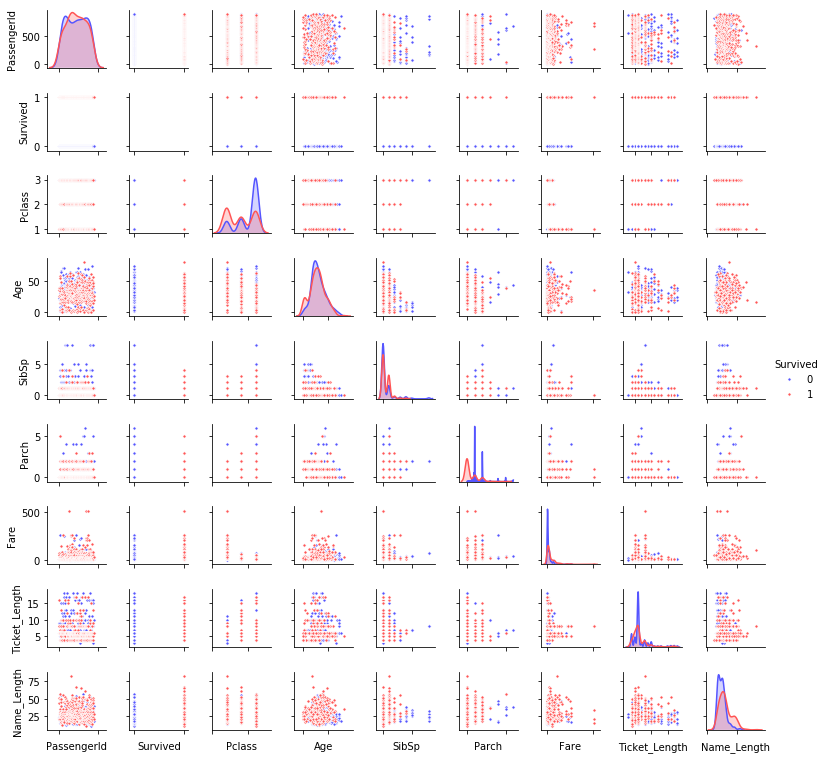

In [46]:
g = sns.pairplot(data=train, hue='Survived', palette = 'seismic',
                 size=1.2,diag_kind = 'kde',diag_kws=dict(shade=True),plot_kws=dict(s=10) )
g.set(xticklabels=[])

## Feature Engineering

*Now wwe have clear idea of dependencies of different fetarue on survival of a person. Let's apply **Feature Engineering** to extract some more features.*

Feature engineering is the art of converting raw data into useful features. There are several feature engineering techniques that you can apply to be an artist.

In [47]:
#first handel the Age 
def age_impute(train, test):
    for i in [train, test]:
        i['Age_Null_Flag'] = i['Age'].apply(lambda x: 1 if pd.isnull(x) else 0)
        data = train.groupby(['Name_Title', 'Pclass'])['Age']
        i['Age'] = data.transform(lambda x: x.fillna(x.mean()))
    return train, test

As we see above **sibsp** and **Parch** are weak feature to decide the survival but with the help of this we can generate the new feature which can effect the survival more.

In [48]:
def family_size(train, test):
    for i in [train, test]:
        i['Family_Size'] = np.where((i['SibSp']+i['Parch']) == 0 , 'Solo',
                           np.where((i['SibSp']+i['Parch']) <= 3,'Nuclear', 'Big'))
        del i['SibSp']
        del i['Parch']
    return train, test


The Ticket column is used to create two new columns: Ticket_Letter, which indicates the first letter of each ticket (with the smaller-n values being grouped based on survival rate); and Ticket_Length, which indicates the length of the Ticket field.

In [49]:
def ticket_grouped(train, test):
    for i in [train, test]:
        i['Ticket_Letter'] = i['Ticket'].apply(lambda x: str(x)[0])
        i['Ticket_Letter'] = i['Ticket_Letter'].apply(lambda x: str(x))
        i['Ticket_Letter'] = np.where((i['Ticket_Letter']).isin(['1', '2', '3', 'S', 'P', 'C', 'A']), i['Ticket_Letter'],
                                   np.where((i['Ticket_Letter']).isin(['W', '4', '7', '6', 'L', '5', '8']),
                                            'Low_ticket', 'Other_ticket'))
        i['Ticket_Length'] = i['Ticket'].apply(lambda x: len(x))
        del i['Ticket']
    return train, test


This first function creates two separate columns: a numeric column indicating the length of a passenger's Name field, and a categorical column that extracts the passenger's title.

In [50]:
def names(train, test):
    for i in [train, test]:
        i['Name_Length'] = i['Name'].apply(lambda x: len(x))
        i['Name_Title'] = i['Name'].apply(lambda x: x.split(',')[1]).apply(lambda x: x.split()[0])
        del i['Name']
    return train, test


**Handling Missing Value**

We fill the null values in the Embarked column with the most commonly occuring value, which is 'S.'

In [51]:
def embarked_impute(train, test):
    for i in [train, test]:
        i['Embarked'] = i['Embarked'].fillna('S')
    return train, test

Handling the missing value of fare columns.

In [52]:
test['Fare'].fillna(train['Fare'].mean(), inplace = True)

**One-Hot-Encoding**

Creating the dummies value for the character value.

In [53]:
def dummies(train, test, columns = ['Pclass', 'Sex', 'Embarked', 'Ticket_Letter', 'Name_Title', 'Family_Size']):
    for column in columns:
        train[column] = train[column].apply(lambda x: str(x))
        test[column] = test[column].apply(lambda x: str(x))
        good_cols = [column+'_'+i for i in train[column].unique() if i in test[column].unique()]
        train = pd.concat((train, pd.get_dummies(train[column], prefix = column)[good_cols]), axis = 1)
        test = pd.concat((test, pd.get_dummies(test[column], prefix = column)[good_cols]), axis = 1)
        del train[column]
        del test[column]
    return train, test

**Droping few column which doesn't useful for prediction**

In [54]:
def drop(train, test, bye = ['PassengerId']):
    for i in [train, test]:
        for z in bye:
            del i[z]
    return train, test

In [55]:
train, test = names(train, test)
train, test = age_impute(train, test)
train, test = embarked_impute(train, test)
train, test = family_size(train, test)
train, test = ticket_grouped(train, test)
train, test = dummies(train, test, columns = ['Pclass', 'Sex', 'Embarked', 'Ticket_Letter','Name_Title', 'Family_Size'])
train, test = drop(train, test)

In [56]:
train.head()

,Survived,Age,Fare,Cabin,Ticket_Length,Name_Length,Age_Null_Flag,Pclass_3,Pclass_1,Pclass_2,Sex_male,Sex_female,Embarked_S,Embarked_C,Embarked_Q,Ticket_Letter_A,Ticket_Letter_P,Ticket_Letter_S,Ticket_Letter_1,Ticket_Letter_3,Ticket_Letter_2,Ticket_Letter_C,Ticket_Letter_Low_ticket,Ticket_Letter_Other_ticket,Name_Title_Mr.,Name_Title_Mrs.,Name_Title_Miss.,Name_Title_Master.,Name_Title_Rev.,Name_Title_Dr.,Name_Title_Ms.,Name_Title_Col.,Family_Size_Nuclear,Family_Size_Solo,Family_Size_Big
0,0,22.0,7.2500,NaN,9,23,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
1,1,38.0,71.2833,C85,8,51,0,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
2,1,26.0,7.9250,NaN,16,22,0,1,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
3,1,35.0,53.1000,C123,6,44,0,0,1,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
4,0,35.0,8.0500,NaN,6,24,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0


In [57]:
test.head()

,Age,Fare,Cabin,Name_Length,Age_Null_Flag,Ticket_Length,Pclass_3,Pclass_1,Pclass_2,Sex_male,Sex_female,Embarked_S,Embarked_C,Embarked_Q,Ticket_Letter_A,Ticket_Letter_P,Ticket_Letter_S,Ticket_Letter_1,Ticket_Letter_3,Ticket_Letter_2,Ticket_Letter_C,Ticket_Letter_Low_ticket,Ticket_Letter_Other_ticket,Name_Title_Mr.,Name_Title_Mrs.,Name_Title_Miss.,Name_Title_Master.,Name_Title_Rev.,Name_Title_Dr.,Name_Title_Ms.,Name_Title_Col.,Family_Size_Nuclear,Family_Size_Solo,Family_Size_Big
0,22.0,7.8292,NaN,16,0,6,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0
1,38.0,7.0000,NaN,32,0,6,1,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
2,26.0,9.6875,NaN,25,0,6,0,0,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0
3,35.0,8.6625,NaN,16,0,6,1,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0
4,35.0,12.2875,NaN,44,0,7,1,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0


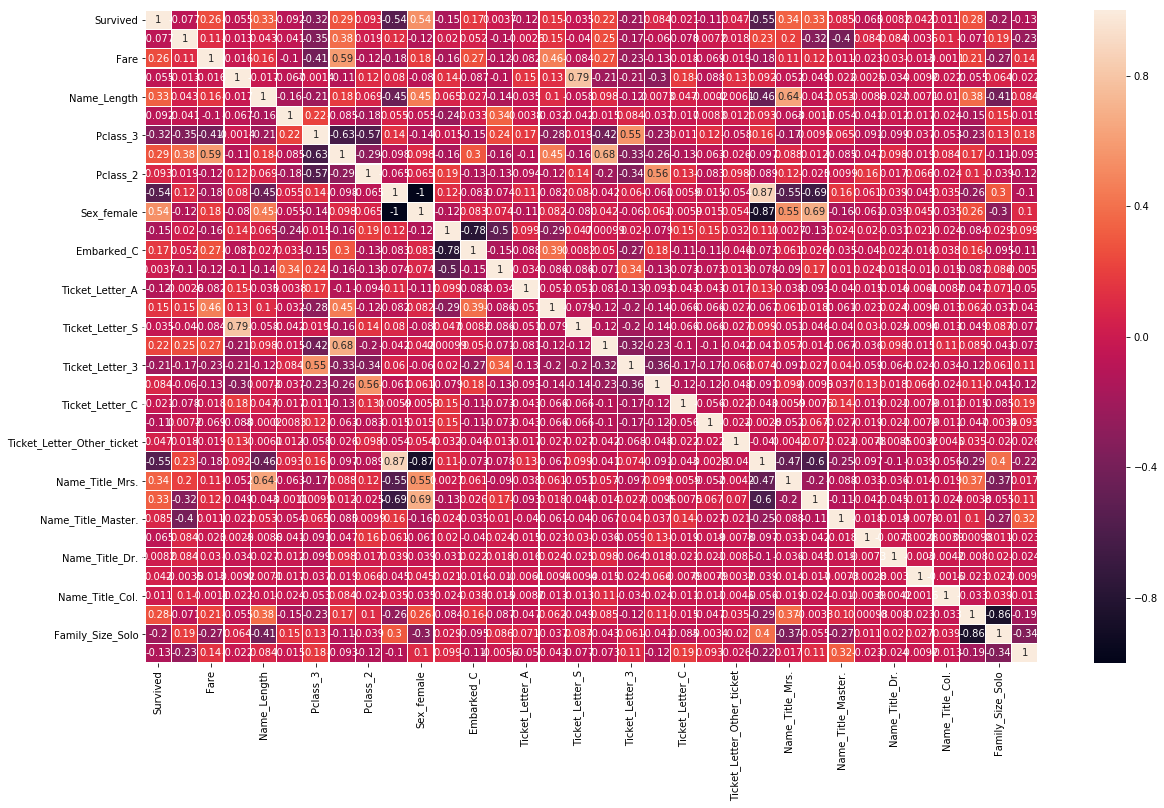

In [58]:
#checking the correlation between features and survival
sns.heatmap(train.corr(),annot=True,linewidths=0.2) 
fig=plt.gcf()
fig.set_size_inches(20,12)
plt.show()

Interpreting The Heatmap The first thing to note is that only the numeric features are compared as it is obvious that we cannot correlate between alphabets or strings. Before understanding the plot, let us see what exactly correlation is.

POSITIVE CORRELATION: If an increase in feature A leads to increase in feature B, then they are positively correlated. A value 1 means perfect positive correlation.

NEGATIVE CORRELATION: If an increase in feature A leads to decrease in feature B, then they are negatively correlated. A value -1 means perfect negative correlation.

Now lets say that two features are highly or perfectly correlated, so the increase in one leads to increase in the other. This means that both the features are containing highly similar information and there is very little or no variance in information. This is known as MultiColinearity as both of them contains almost the same information.

So do you think we should use both of them as one of them is redundant. While making or training models, we should try to eliminate redundant features as it reduces training time and many such advantages.

We can put the cabin column in dataset but there is lot of missing value in it which may reduce the model performance.It give accuracy of 82%.so we drop the Cabin column.

In [59]:
drop_column = ['Cabin']
train.drop(drop_column, axis=1, inplace = True)
test.drop(drop_column, axis=1, inplace = True)

In [60]:
#Final Check the train dataset
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 34 columns):
Survived                      891 non-null int64
Age                           891 non-null float64
Fare                          891 non-null float64
Ticket_Length                 891 non-null int64
Name_Length                   891 non-null int64
Age_Null_Flag                 891 non-null int64
Pclass_3                      891 non-null uint8
Pclass_1                      891 non-null uint8
Pclass_2                      891 non-null uint8
Sex_male                      891 non-null uint8
Sex_female                    891 non-null uint8
Embarked_S                    891 non-null uint8
Embarked_C                    891 non-null uint8
Embarked_Q                    891 non-null uint8
Ticket_Letter_A               891 non-null uint8
Ticket_Letter_P               891 non-null uint8
Ticket_Letter_S               891 non-null uint8
Ticket_Letter_1               891 non-null uint8
Ticket_Le

In [61]:
#Final Check for Test dataset
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 33 columns):
Age                           418 non-null float64
Fare                          418 non-null float64
Name_Length                   418 non-null int64
Age_Null_Flag                 418 non-null int64
Ticket_Length                 418 non-null int64
Pclass_3                      418 non-null uint8
Pclass_1                      418 non-null uint8
Pclass_2                      418 non-null uint8
Sex_male                      418 non-null uint8
Sex_female                    418 non-null uint8
Embarked_S                    418 non-null uint8
Embarked_C                    418 non-null uint8
Embarked_Q                    418 non-null uint8
Ticket_Letter_A               418 non-null uint8
Ticket_Letter_P               418 non-null uint8
Ticket_Letter_S               418 non-null uint8
Ticket_Letter_1               418 non-null uint8
Ticket_Letter_3               418 non-null uint8
Ticket_Le

## Applying the ML Model

In [62]:
from sklearn.svm import SVC
classifier_svc = SVC(kernel = 'rbf',random_state = 0)
classifier_svc.fit(train.iloc[:, 1:], train.iloc[:, 0])

/opt/conda/lib/python3.6/site-packages/sklearn/svm/base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='rbf', max_iter=-1, probability=False, random_state=0,
  shrinking=True, tol=0.001, verbose=False)

In [63]:
print(classifier_svc.score(train.iloc[:, 1:], train.iloc[:, 0]))

0.9135802469135802


In [64]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(criterion='gini', 
                             n_estimators=700,
                             min_samples_split=10,
                             min_samples_leaf=1,
                             max_features='auto',
                             oob_score=True,
                             random_state=1,
                             n_jobs=-1)

classifier.fit(train.iloc[:, 1:], train.iloc[:, 0])

print("%.4f" % classifier.oob_score_)

0.8373


In [65]:
print(classifier.score(train.iloc[:, 1:], train.iloc[:, 0]))

0.9113355780022446


In [66]:
from sklearn import model_selection
scores = model_selection.cross_val_score(classifier, train.iloc[:, 1:], train.iloc[:, 0], scoring = 'accuracy', cv = 10)

In [67]:
print(scores)

[0.81111111 0.84444444 0.76404494 0.87640449 0.85393258 0.85393258
 0.83146067 0.78651685 0.84269663 0.85227273]


In [68]:
prediction_forest = classifier.predict(test)

In [69]:
predictions = pd.DataFrame(prediction_forest, columns=['Survived'])
test = pd.read_csv(os.path.join('../input', 'test.csv'))
predictions = pd.concat((test.iloc[:, 0], predictions), axis = 1)
predictions.to_csv('output.csv', sep=",", index = False)

In [70]:
predictions.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


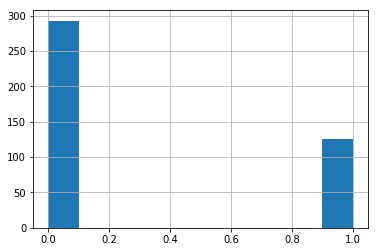

In [71]:
predictions['Survived'].hist()

# End notes...

## <font color='blue'>I hope you find this kernel useful and enjoyable.Please upvote it.</font>

### Your comments and feedback are most welcome.